In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load built-in Breast Cancer dataset
data = load_breast_cancer()

# Load features into DataFrame and target into array
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Target classes: 0 = Malignant, 1 = Benign

In [3]:
# Stratify ensures class distributions are preserved across splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
scaler = StandardScaler()

# Fit and transform on train set; transform only on test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Baseline Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

In [6]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
## Step 7: Precision, Recall & F1-Score Interpretation

### 1. Which metric is more important for medical diagnosis?
**Recall** is the most critical metric. In medical diagnosis (such as breast cancer screening), failing to identify a malignant tumor (a False Negative) can be fatal because the patient misses critical early treatment. A False Positive only results in additional follow-up testing. Therefore, we prioritize maximizing Recall to minimize False Negatives.

### 2. What happens if recall is low?
If Recall is low, the model produces a high number of **False Negatives**. In a real-world healthcare setting, this means many patients who actually have malignant tumors will be incorrectly told they are healthy, providing a dangerous false sense of security and delaying life-saving care.

### 3. Why is F1-Score preferred for imbalanced data?
Accuracy can be highly misleading on imbalanced datasets because a model that always predicts the majority class can easily achieve high accuracy while completely missing the minority class. The **F1-Score** is the harmonic mean of Precision and Recall. It provides a balanced assessment of model performance by penalizing models that trade off one metric heavily for the other.

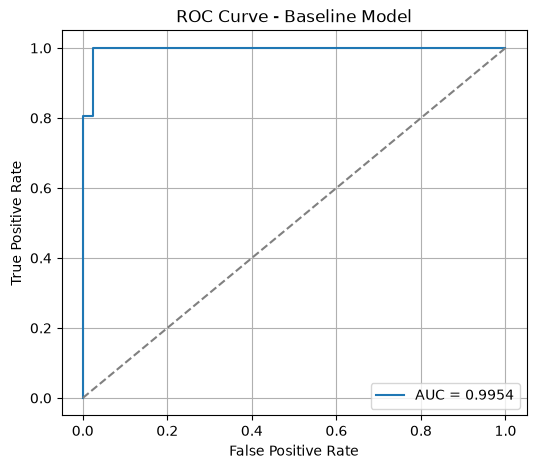

In [8]:
# Obtain probability predictions for the positive class (1)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Model with balanced class weights to compensate for imbalanced data
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced Model Classification Report:\n")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
# Train Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # Decision trees do not require scaling

y_pred_tree = tree.predict(X_test)

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

